# Goal of the analysis

What determines the price of a ski lift pass worldwide? We identify four groups of factors ("suspects") and test each with the appropriate statistical tests.

## The four categories

1. **The Mountain Itself** — do bigger, higher resorts charge more?
2. **Geography and Wealth** — does location and country wealth drive pricing?
3. **Services and Positioning** — do extras (snowparks, summer skiing) justify a premium?
4. **The Actual Snow** — does mean snow cover correlate with price?

## Libraries 

In [2]:
#install.packages("rio")
#install.packages("dplyr")
#install.packages("rcompanion")
#install.packages("sjmisc")
#install.packages("ggplot2")
library(rio)
library(dplyr)

library(rcompanion)
library(ggplot2)


Caricamento pacchetto: 'dplyr'


I seguenti oggetti sono mascherati da 'package:stats':

    filter, lag


I seguenti oggetti sono mascherati da 'package:base':

    intersect, setdiff, setequal, union




In [3]:
# House colour reused across the charts
blue <- "#2c7fb8"

## Data importing and cleaning

*Ski Resorts* (Kaggle): 499 resorts, 25 variables (location, structure, services, price). Read as Latin-1 for accented resort names. A separate `snow.csv` holds 2022 monthly snow cover by coordinate.

In [4]:
resorts <- import("data/resorts.csv", encoding = "Latin-1")

str(resorts)
nrow(resorts)
ncol(resorts)

'data.frame':	499 obs. of  25 variables:
 $ ID                 : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Resort             : chr  "Hemsedal" "Geilosiden Geilo" "Golm" "Red Mountain Resort-Rossland" ...
 $ Latitude           : num  60.9 60.5 47.1 49.1 61.2 ...
 $ Longitude          : num  8.38 8.21 9.83 -117.85 10.53 ...
 $ Country            : chr  "Norway" "Norway" "Austria" "Canada" ...
 $ Continent          : chr  "Europe" "Europe" "Europe" "North America" ...
 $ Price              : int  46 44 48 60 45 43 61 57 22 20 ...
 $ Season             : chr  "November - May" "November - April" "December - April" "December - April" ...
 $ Highest point      : int  1450 1178 2110 2075 1030 960 1980 2700 1385 1554 ...
 $ Lowest point       : int  620 800 650 1185 195 284 1300 1600 1030 1300 ...
 $ Beginner slopes    : int  29 18 13 20 33 25 5 10 4 7 ...
 $ Intermediate slopes: int  10 12 12 50 7 4 0 15 0 1 ...
 $ Difficult slopes   : int  4 4 1 50 4 11 5 10 0 0 ...
 $ Total slopes       : int  43 34

[1] 499

[1] 25

# Data Cleaning and Preparation {#sec-cleaning}

In [5]:
summary(resorts)
table(resorts$Continent)

       ID              Resort       Latitude        Longitude       
 Min.   :  1.0   Length   :499   Min.   :-45.05   Min.   :-149.741  
 1st Qu.:125.5   N.unique :499   1st Qu.: 43.67   1st Qu.:   1.381  
 Median :250.0   N.blank  :  0   Median : 46.35   Median :   8.206  
 Mean   :250.0   Min.nchar:  3   Mean   : 43.21   Mean   :  -6.007  
 3rd Qu.:374.5   Max.nchar:107   3rd Qu.: 47.33   3rd Qu.:  12.429  
 Max.   :499.0                   Max.   : 67.78   Max.   : 176.877  
      Country        Continent       Price              Season   
 Length   :499   Length   :499   Min.   :  0.00   Length   :499  
 N.unique : 38   N.unique :  5   1st Qu.: 36.00   N.unique : 31  
 N.blank  :  0   N.blank  :  0   Median : 45.00   N.blank  :  0  
 Min.nchar:  4   Min.nchar:  4   Mean   : 48.72   Min.nchar:  3  
 Max.nchar: 22   Max.nchar: 13   3rd Qu.: 54.00   Max.nchar: 51  
                                 Max.   :141.00                  
 Highest point   Lowest point  Beginner slopes  Interme


         Asia        Europe North America       Oceania South America 
           24           360            98            10             7 

Mostly Europe (360 of 499) and North America (98); Oceania (10) and South America (7) are underrepresented — worth remembering when interpreting their results.


## Detecting Missing Values

In [6]:
#check for explicit ones
apply(resorts, 2, function(x) sum(is.na(x)))

ID              Resort            Latitude           Longitude 
                  0                   0                   0                   0 
            Country           Continent               Price              Season 
                  0                   0                   0                   0 
      Highest point        Lowest point     Beginner slopes Intermediate slopes 
                  0                   0                   0                   0 
   Difficult slopes        Total slopes         Longest run        Snow cannons 
                  0                   0                   0                   0 
      Surface lifts         Chair lifts       Gondola lifts         Total lifts 
                  0                   0                   0                   0 
      Lift capacity      Child friendly           Snowparks         Nightskiing 
                  0                   0                   0                   0 
      Summer skiing 
                  0

Now looking for large quantities of zeros that might be hidden NAs

In [7]:
colonne_num <- sapply(resorts, is.numeric)
apply(resorts[, colonne_num], 2, function(x) sum(x == 0, na.rm = TRUE))

ID            Latitude           Longitude               Price 
                  0                   0                   0                   9 
      Highest point        Lowest point     Beginner slopes Intermediate slopes 
                  0                   0                   4                   5 
   Difficult slopes        Total slopes         Longest run        Snow cannons 
                 35                   0                 212                 226 
      Surface lifts         Chair lifts       Gondola lifts         Total lifts 
                 18                  14                 175                   1 
      Lift capacity 
                  3

**Interpretation of the zeros found:**

-   `Price`: 9 zeros → impossible (a ski pass cannot be free) → **masked NAs**
-   `Total lifts`: 1 zero → impossible (a ski resort needs lifts) → **masked NA**
-   `Beginner / Intermediate / Difficult slopes`: plausible (a resort may lack a difficulty tier)
-   `Snow cannons` (226), `Gondola lifts` (175): plausible (small resorts often lack these)
-   `Longest run` (212): suspicious but ambiguous, we keep them for now

In [8]:
# Convert zeros to NA
resorts$Price <- ifelse(resorts$Price == 0, NA, resorts$Price)
resorts$`Total lifts` <- ifelse(resorts$`Total lifts` == 0, NA, resorts$`Total lifts`)

apply(resorts, 2, function(x) sum(is.na(x)))

ID              Resort            Latitude           Longitude 
                  0                   0                   0                   0 
            Country           Continent               Price              Season 
                  0                   0                   9                   0 
      Highest point        Lowest point     Beginner slopes Intermediate slopes 
                  0                   0                   0                   0 
   Difficult slopes        Total slopes         Longest run        Snow cannons 
                  0                   0                   0                   0 
      Surface lifts         Chair lifts       Gondola lifts         Total lifts 
                  0                   0                   0                   1 
      Lift capacity      Child friendly           Snowparks         Nightskiing 
                  0                   0                   0                   0 
      Summer skiing 
                  0

## `Season` Variable

27 entities marked as `"Unknown"`.

In [9]:
table(resorts$Season)
length(unique(resorts$Season))


                                              April 
                                                  5 
                                           December 
                                                  2 
                                   December - April 
                                                220 
December - April, June - August, October - November 
                                                  1 
                                   December - March 
                                                 40 
                                     December - May 
                                                  7 
                                               July 
                                                  1 
                                       July - April 
                                                  1 
                                     July - October 
                                                  1 
                                   July - Sep

[1] 31

Dividing the months in actual season:
-   **Winter_Only**: winter season (Nov–May)
-   **Summer_Only**: summer months only (glaciers)
-   **Multi_Season**: open both in winter and summer
-   **Year_Round**: open all year
-   **NA**: previously "Unknown"


In [10]:
# define values for each category
seasons_winter <- c("December - April", "November - April", "December - March",
                    "November - May", "October - May", "December - May",
                    "October - April", "April", "October - June", "September - June",
                    "September - May", "March", "December", "July - April",
                    "November - June", "September - April", "November - March")

seasons_summer <- c("June - October", "June - September", "July - September",
                    "May - September", "July", "May - October", "May",
                    "July - October")

seasons_multi <- c("November - May, June - August",
                   "December - April, June - August, October - November",
                   "October - November, December - May, June - October")

resorts$Season <- ifelse(resorts$Season == "Unknown", NA,
                  ifelse(resorts$Season == "Year-round", "Year_Round",
                  ifelse(resorts$Season %in% seasons_multi, "Multi_Season",
                  ifelse(resorts$Season %in% seasons_summer, "Summer_Only",
                  ifelse(resorts$Season %in% seasons_winter, "Winter_Only", NA)))))

table(resorts$Season, useNA = "ifany")


Multi_Season  Summer_Only  Winter_Only   Year_Round         <NA> 
           4           20          443            4           28 

## Derived Variables

creating the ones we find useful

In [11]:
resorts <- mutate(resorts, Vertical_Drop = `Highest point` - `Lowest point`)

resorts$Altitude_Band <- cut(resorts$`Highest point`,
                             breaks = c(0, 1500, 2500, 3500, 5000),
                             labels = c("Low", "Medium", "High", "Very_High"))

table(resorts$Altitude_Band)


      Low    Medium      High Very_High 
      111       221       147        20 

## Loading External Datasets

Two World Bank (2022) indicators enrich the analysis:

- **GDP per capita** (US$) — proxy for national wealth.
- **PPP** — proxy for local cost of living / purchasing power.

Both come from the same source, so country names only need reconciling once. The raw files use the World Bank layout (metadata preamble + one column per year), so they are cleaned into tidy `*_clean.csv` files first.

### Preparing the World Bank files

The cell below cleans both raw files once: skip the preamble, keep Country + the 2022 value, align country names to the resorts data, and write tidy two-column `*_clean.csv` files (kept beside the `_raw` ones for reproducibility).

In [12]:
clean_worldbank <- function(path_raw, value_name, year = "2022") {
  raw <- import(path_raw, skip = 4, header = TRUE)   # skip the 4-line metadata preamble

  clean <- data.frame(
    Country = raw[["Country Name"]],
    value   = as.numeric(raw[[year]]),
    stringsAsFactors = FALSE
  )
  names(clean)[2] <- value_name

  # Align World Bank country names with the resorts dataset spelling
  rename_map <- c(
    "Czechia"            = "Czech Republic",
    "Korea, Rep."        = "South Korea",
    "Russian Federation" = "Russia",
    "Slovak Republic"    = "Slovakia",
    "Turkiye"            = "Turkey",
    "Iran, Islamic Rep." = "Iran",
    "Kyrgyz Republic"    = "Kyrgyzstan"
  )
  to_fix <- clean$Country %in% names(rename_map)
  clean$Country[to_fix] <- rename_map[clean$Country[to_fix]]

  clean
}

gdp_clean <- clean_worldbank("data/gdp_per_capita_raw.csv", "GDP_per_capita")
ppp_clean <- clean_worldbank("data/ppp_raw.csv",            "PPP")

export(gdp_clean, "data/gdp_per_capita_clean.csv")
export(ppp_clean, "data/ppp_clean.csv")

In [13]:
# Load the cleaned files and merge on Country
gdp <- import("data/gdp_per_capita_clean.csv")
ppp <- import("data/ppp_clean.csv")

resorts <- merge(resorts, gdp, by = "Country", all.x = TRUE)
resorts <- merge(resorts, ppp, by = "Country", all.x = TRUE)

# Countries that failed to match (expect only genuine gaps, e.g. no PPP for Liechtenstein)
unique(resorts$Country[is.na(resorts$GDP_per_capita)])
unique(resorts$Country[is.na(resorts$PPP)])

character(0)

[1] "Liechtenstein"

**Country-name alignment** is handled by `rename_map` in the cleaning cell, so one map fixes both merges. After merging, every resort country has GDP; only **Liechtenstein** lacks PPP (a genuine World Bank gap).

# Descriptive Overview

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  14.00   37.00   46.00   49.62   54.75  141.00       9 

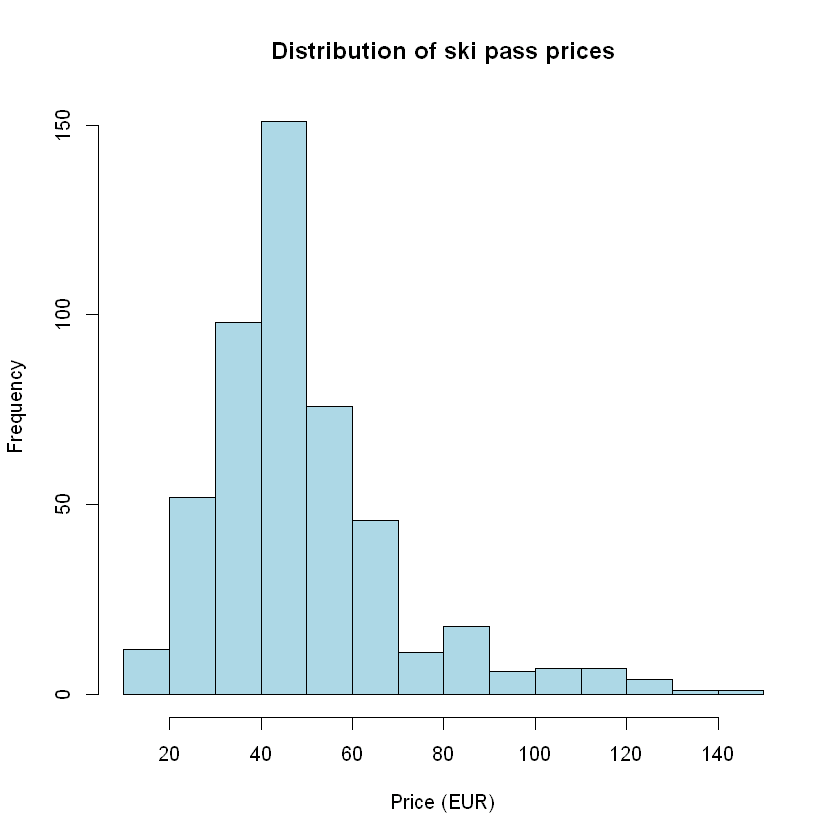

In [14]:
# Price distribution
summary(resorts$Price)
hist(resorts$Price,
     main = "Distribution of ski pass prices",
     xlab = "Price (EUR)",
     col = "lightblue")

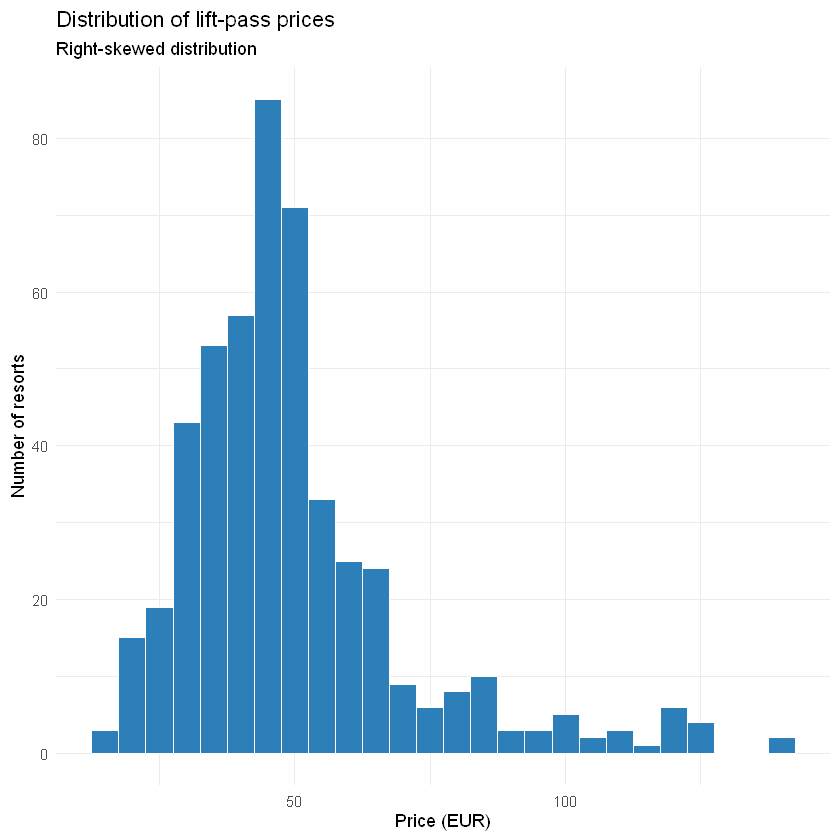

In [15]:
# Plot: price distribution ----------------------------------
p_price <- ggplot(filter(resorts, !is.na(Price)), aes(x = Price)) +
  geom_histogram(binwidth = 5, fill = blue, colour = "white") +
  labs(title = "Distribution of lift-pass prices",
       subtitle = "Right-skewed distribution",
       x = "Price (EUR)", y = "Number of resorts") +
  theme_minimal()

p_price

The mean (51.4 EUR) exceeds the median (45 EUR) → **right-skewed**: a few premium resorts pull the average up.

# Suspect 1 — The Mountain Itself

**Hypothesis:** larger/higher resorts charge more (more terrain, more infrastructure to maintain).

## Correlation Tests

- H0: correlation = 0 (no linear relationship)
- H1: correlation ≠ 0

In [16]:
# Price vs maximum altitude
cor.test(resorts$`Highest point`, resorts$Price, use = "pairwise.complete.obs")

# Price vs total number of slopes
cor.test(resorts$`Total slopes`, resorts$Price, use = "pairwise.complete.obs")

# Price vs total number of lifts
cor.test(resorts$`Total lifts`, resorts$Price, use = "pairwise.complete.obs")

# Price vs vertical drop
cor.test(resorts$Vertical_Drop, resorts$Price, use = "pairwise.complete.obs")


	Pearson's product-moment correlation

data:  resorts$`Highest point` and resorts$Price
t = 9.7934, df = 488, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.3284974 0.4767516
sample estimates:
      cor 
0.4052857 



	Pearson's product-moment correlation

data:  resorts$`Total slopes` and resorts$Price
t = 7.1011, df = 488, p-value = 4.398e-12
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.2235080 0.3841972
sample estimates:
      cor 
0.3060306 



	Pearson's product-moment correlation

data:  resorts$`Total lifts` and resorts$Price
t = 2.2946, df = 487, p-value = 0.02218
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.0148856 0.1903480
sample estimates:
      cor 
0.1034214 



	Pearson's product-moment correlation

data:  resorts$Vertical_Drop and resorts$Price
t = 3.7949, df = 488, p-value = 0.0001663
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.08195443 0.25407810
sample estimates:
     cor 
0.169307 


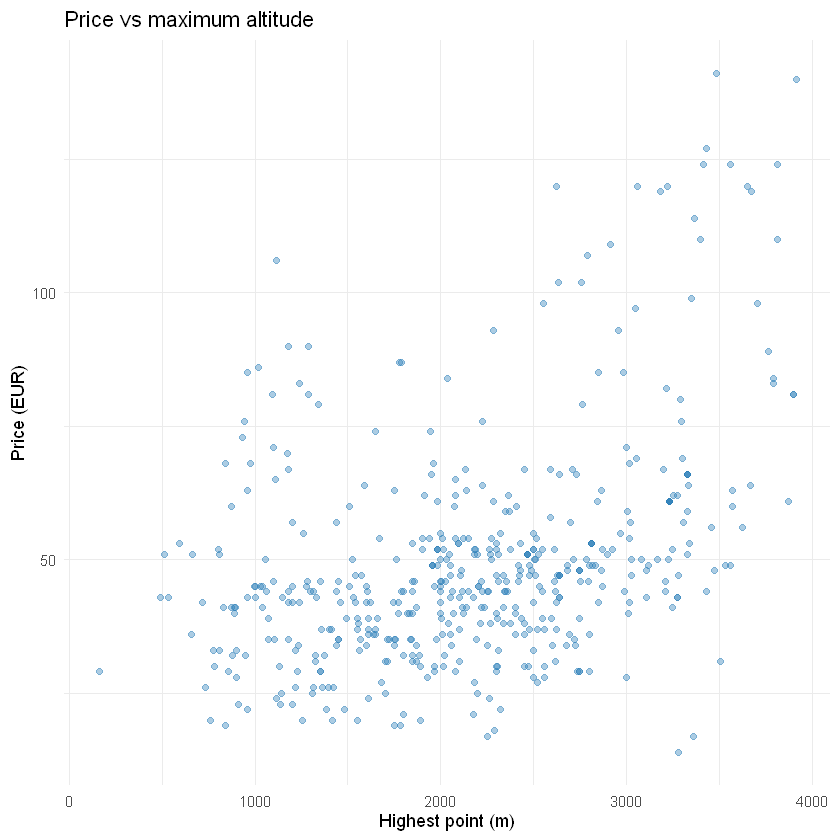

In [17]:
# Plot: price vs maximum altitude ---------------------------
p_alt <- ggplot(filter(resorts, !is.na(Price)),
                aes(x = `Highest point`, y = Price)) +
  geom_point(alpha = 0.4, colour = blue) +
  labs(title = "Price vs maximum altitude",
       x = "Highest point (m)", y = "Price (EUR)") +
  theme_minimal()

p_alt

**Findings:**

- `Highest point`: r ≈ 0.41, p < 0.001 — moderate positive
- `Total slopes`: r ≈ 0.31, p < 0.001 — moderate positive
- `Total lifts`: r ≈ 0.10, p ≈ 0.02 — weak but significant
- `Vertical_Drop`: r ≈ 0.17, p < 0.001 — weak but significant

Strongest single predictor: **maximum altitude**.

## ANOVA: Price by Altitude Band

- H0: mean price equal across altitude bands
- H1: at least one band differs

In [18]:
anova_altitude <- aov(Price ~ Altitude_Band, data = resorts)
summary(anova_altitude)
TukeyHSD(anova_altitude)

               Df Sum Sq Mean Sq F value Pr(>F)    
Altitude_Band   3  43229   14410   41.21 <2e-16 ***
Residuals     486 169923     350                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
9 osservazioni eliminate a causa di valori mancanti

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Price ~ Altitude_Band, data = resorts)

$Altitude_Band
                       diff       lwr       upr     p adj
Medium-Low        0.5183486 -5.136399  6.173097 0.9953517
High-Low         13.8433951  7.714250 19.972540 0.0000001
Very_High-Low    40.6119266 28.885991 52.337862 0.0000000
High-Medium      13.3250465  8.137784 18.512309 0.0000000
Very_High-Medium 40.0935780 28.831303 51.355853 0.0000000
Very_High-High   26.7685315 15.260748 38.276315 0.0000000


## Preliminary Conclusion for Suspect 1

> Maximum altitude and number of slopes relate positively to price, but only moderately — "bigger = more expensive" is only part of the story.

# Suspect 2 — Geography and Wealth

**Hypothesis:** prices vary by region because of each country's economic context (purchasing power, cost of living, tourism market).

## Price by Continent

In [19]:
resorts %>%
  group_by(Continent) %>%
  summarise(
    N = n(),
    Mean_Price = round(mean(Price, na.rm = TRUE), 2),
    Median_Price = median(Price, na.rm = TRUE),
    SD_Price = round(sd(Price, na.rm = TRUE), 2)
  )

Continent,N,Mean_Price,Median_Price,SD_Price
<chr>,<int>,<dbl>,<dbl>,<dbl>
Asia,24,39.10,41,11.10
Europe,360,41.90,43,10.83
North America,98,77.76,70,25.50
Oceania,10,70.33,74,14.92
South America,7,56.71,57,7.20


## ANOVA: Price by Continent

**Hypotheses:**

-   H0: mean price is equal across all continents
-   H1: at least one continent has a significantly different mean price

In [20]:
anova_continent <- aov(Price ~ Continent, data = resorts)
summary(anova_continent)
TukeyHSD(anova_continent)

             Df Sum Sq Mean Sq F value Pr(>F)    
Continent     4 104550   26137   116.7 <2e-16 ***
Residuals   485 108602     224                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
9 osservazioni eliminate a causa di valori mancanti

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Price ~ Continent, data = resorts)

$Continent
                                  diff         lwr       upr     p adj
Europe-Asia                   2.796359  -6.6184988 12.211216 0.9265291
North America-Asia           38.662887  28.6008883 48.724885 0.0000000
Oceania-Asia                 31.233333  14.7875366 47.679130 0.0000029
South America-Asia           17.614286  -0.3789818 35.607553 0.0583539
North America-Europe         35.866528  31.1751533 40.557903 0.0000000
Oceania-Europe               28.436975  14.6084022 42.265547 0.0000003
South America-Europe         14.817927  -0.8192997 30.455154 0.0729114
Oceania-North America        -7.429553 -21.7065869  6.847480 0.6118908
South America-North America -21.048601 -37.0837852 -5.013417 0.0032884
South America-Oceania       -13.619048 -34.2672329  7.029138 0.3712467


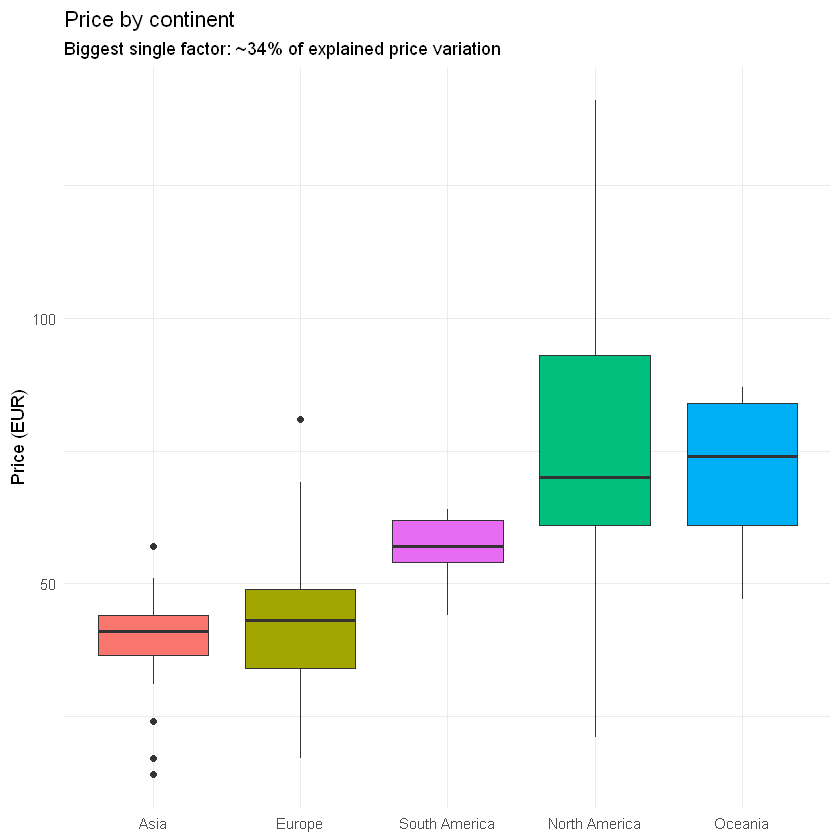

In [21]:
# Plot: price by continent ----------------------------------
cont_data <- filter(resorts, !is.na(Price) & !is.na(Continent))
p_cont <- ggplot(cont_data,
                 aes(x = reorder(Continent, Price, FUN = median),
                     y = Price, fill = Continent)) +
  geom_boxplot(show.legend = FALSE) +
  labs(title = "Price by continent",
       subtitle = "Biggest single factor: ~34% of explained price variation",
       x = NULL, y = "Price (EUR)") +
  theme_minimal()

p_cont

## Correlation with National Wealth and Cost of Living

Two complementary questions:

- **GDP per capita** → do prices reflect national wealth?
- **PPP** → do prices reflect local cost of living / purchasing power?

The two need not align: a country can be wealthy *and* expensive (Norway) or wealthy but mid-priced (USA).

In [22]:
# Correlation: price vs GDP per capita (national wealth)
cor.test(resorts$GDP_per_capita, resorts$Price, use = "pairwise.complete.obs")

# Correlation: price vs PPP (local cost of living proxy)
cor.test(resorts$PPP, resorts$Price, use = "pairwise.complete.obs")


	Pearson's product-moment correlation

data:  resorts$GDP_per_capita and resorts$Price
t = 11.052, df = 488, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.3736601 0.5155790
sample estimates:
     cor 
0.447432 



	Pearson's product-moment correlation

data:  resorts$PPP and resorts$Price
t = -0.87123, df = 487, p-value = 0.3841
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1276739  0.0493968
sample estimates:
        cor 
-0.03944825 


## Preliminary Conclusion for Suspect 2

> *To be written based on results.* Expected: North American resorts charge
> substantially more, and this gap is partly — but probably not fully —
> explained by differences in national wealth and cost of living.

# Suspect 3 — Services and Commercial Positioning 

**Hypothesis:** additional services (snowparks, night skiing, summer skiing,
family-friendly facilities) command a price premium because they target
specific customer segments willing to pay more.

## Service Variables Distribution

In [24]:
table(resorts$Snowparks)
table(resorts$Nightskiing)
table(resorts$`Summer skiing`)
table(resorts$`Child friendly`)


 No Yes 
121 378 


 No Yes 
295 204 


 No Yes 
470  29 


 No Yes 
  4 495 

## T-tests: Price by Each Service

**Hypotheses (for each service):**

-   H0: mean price is the same for resorts with vs without the service
-   H1: mean price differs between resorts with vs without the service

In [25]:
# Snowpark
t.test(resorts$Price[resorts$Snowparks == "Yes"],
       resorts$Price[resorts$Snowparks == "No"])

# Night skiing
t.test(resorts$Price[resorts$Nightskiing == "Yes"],
       resorts$Price[resorts$Nightskiing == "No"])

# Summer skiing
t.test(resorts$Price[resorts$`Summer skiing` == "Yes"],
       resorts$Price[resorts$`Summer skiing` == "No"])

# Child friendly
t.test(resorts$Price[resorts$`Child friendly` == "Yes"],
       resorts$Price[resorts$`Child friendly` == "No"])


	Welch Two Sample t-test

data:  resorts$Price[resorts$Snowparks == "Yes"] and resorts$Price[resorts$Snowparks == "No"]
t = 4.4291, df = 202.14, p-value = 1.549e-05
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
  5.16222 13.44648
sample estimates:
mean of x mean of y 
 51.80000  42.49565 



	Welch Two Sample t-test

data:  resorts$Price[resorts$Nightskiing == "Yes"] and resorts$Price[resorts$Nightskiing == "No"]
t = -0.63665, df = 479.23, p-value = 0.5247
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -4.801252  2.451349
sample estimates:
mean of x mean of y 
 48.92574  50.10069 



	Welch Two Sample t-test

data:  resorts$Price[resorts$`Summer skiing` == "Yes"] and resorts$Price[resorts$`Summer skiing` == "No"]
t = 4.1262, df = 33.001, p-value = 0.0002348
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
  6.581316 19.384052
sample estimates:
mean of x mean of y 
 61.85714  48.87446 



	Welch Two Sample t-test

data:  resorts$Price[resorts$`Child friendly` == "Yes"] and resorts$Price[resorts$`Child friendly` == "No"]
t = 0.3471, df = 3.0432, p-value = 0.7511
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -31.55762  39.35392
sample estimates:
mean of x mean of y 
 49.64815  45.75000 


## ANOVA: Price by Seasonality

`Year_Round` and `Multi_Season` are tiny (4 each), so this is exploratory.

- H0: mean price equal across seasonality types
- H1: at least one differs

In [26]:
anova_season <- aov(Price ~ Season, data = resorts)
summary(anova_season)
TukeyHSD(anova_season)

             Df Sum Sq Mean Sq F value Pr(>F)  
Season        3   3849    1283   2.916 0.0339 *
Residuals   460 202381     440                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
35 osservazioni eliminate a causa di valori mancanti

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Price ~ Season, data = resorts)

$Season
                                diff       lwr        upr     p adj
Summer_Only-Multi_Season  -2.8289474 -32.58131 26.9234188 0.9948172
Winter_Only-Multi_Season -14.7625858 -41.92779 12.4026181 0.4991952
Year_Round-Multi_Season   -3.5000000 -41.74277 34.7427744 0.9953705
Winter_Only-Summer_Only  -11.9336384 -24.60809  0.7408165 0.0733401
Year_Round-Summer_Only    -0.6710526 -30.42342 29.0813136 0.9999293
Year_Round-Winter_Only    11.2625858 -15.90262 38.4277897 0.7086030


## Preliminary Conclusion for Suspect 3

> *To be written based on results.* Expected: services like snowparks and
> night skiing add a measurable premium, but summer skiing is geographically
> determined (Southern Hemisphere / glaciers) rather than a pure positioning
> choice.

# Suspect 4 — The Actual Snow 

**Hypothesis:** resorts with more reliable natural snow cover can charge
higher prices because they offer a better and more predictable skiing
experience.

## Loading the Snow Dataset

In [27]:
snow <- import("data/snow.csv")
str(snow)
nrow(snow)
# Monthly snow values per grid point: Month, Latitude, Longitude, Snow (2022)

'data.frame':	820522 obs. of  4 variables:
 $ Month    : IDate, format: "2022-12-01" "2022-12-01" ...
 $ Latitude : num  63.1 63.1 63.1 63.1 63.1 ...
 $ Longitude: num  68.9 69.1 69.4 69.6 69.9 ...
 $ Snow     : num  95.3 100 100 100 100 ...


[1] 820522

## Aggregating Snow Data per Resort

Snow values sit on a regular 0.25-degree grid whose cell centres fall at .125 offsets (e.g. 63.125, 68.875). We snap each resort coordinate to the centre of the cell that contains it, aggregate snow per cell, and attach it to each resort. (Rounding to the .0/.25/.5/.75 lattice instead, as `round(x * 4) / 4` does, misaligns with the grid and matches only 125/499 resorts.)

In [28]:
# The snow data sits on a regular 0.25-degree grid whose cell CENTRES fall
# at .125 offsets (e.g. 63.125, 68.875), not on the .0/.25/.5/.75 lattice.
# Rounding with round(x * 4) / 4 therefore snaps to the wrong lattice and
# lands snow points on .5 rounding boundaries, so only 125/499 resorts match.
# Instead, snap each coordinate to the centre of the 0.25-deg cell that
# contains it, so resorts and snow share identical keys.
snap_grid <- function(x) floor(x / 0.25) * 0.25 + 0.125

snow_agg <- snow %>%
  mutate(Lat_key = snap_grid(Latitude),
         Lon_key = snap_grid(Longitude)) %>%
  group_by(Lat_key, Lon_key) %>%
  summarise(Mean_Snow = mean(Snow, na.rm = TRUE),
            Max_Snow = max(Snow, na.rm = TRUE),
            .groups = "drop")

# Add the same keys to resorts, then merge snow on
resorts <- mutate(resorts,
                  Lat_key = snap_grid(Latitude),
                  Lon_key = snap_grid(Longitude))
resorts <- merge(resorts, snow_agg,
                 by = c("Lat_key", "Lon_key"), all.x = TRUE)

sum(!is.na(resorts$Mean_Snow))   # resorts matched

[1] 477

In [29]:
# The 125 resorts that matched a snow grid cell, with their country
matched_resorts <- resorts %>%
  filter(!is.na(Mean_Snow)) %>%
  select(Resort, Country) %>%
  arrange(Country, Resort)

cat("Resorts matched to snow data:", nrow(matched_resorts), "

")
print(matched_resorts, row.names = FALSE)

Resorts matched to snow data: 125 

                                                                                   Resort
                                                        Pal-?Arinsal-La Massana-Vallnord-
                                                                                 Perisher
                                                                           Dachstein West
                                                Fellhorn-?Kanzelwand-Oberstdorf-?Riezlern
                                   Fieberbrunn - Saalbach Hinterglemm Leogang (Skicircus)
                                                                                Gargellen
                                                          Großglockner Resort Kals-Matrei
                                                 Hochko?nig-Maria Alm/?Dienten/?Mu?hlbach
                                                                               Katschberg
                                                                

## Correlation: Snow vs Price

**Hypotheses:**

-   H0: there is no linear relationship between snow cover and price
-   H1: there is a linear relationship between snow cover and price

In [30]:
cor.test(resorts$Mean_Snow, resorts$Price, use = "pairwise.complete.obs")


	Pearson's product-moment correlation

data:  resorts$Mean_Snow and resorts$Price
t = 0.51828, df = 118, p-value = 0.6052
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1327175  0.2249771
sample estimates:
       cor 
0.04765753 


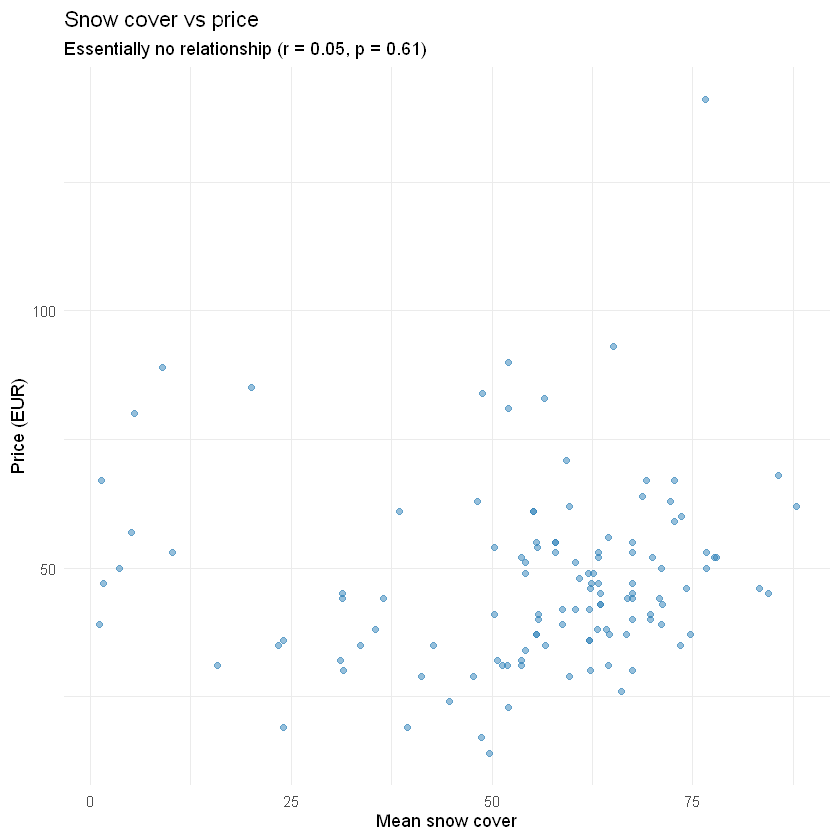

In [31]:
# Snow vs price (Suspect 4) ---------------------------------------------------
snow_plot_data <- filter(resorts, !is.na(Mean_Snow) & !is.na(Price))
p_snow <- ggplot(snow_plot_data, aes(x = Mean_Snow, y = Price)) +
  geom_point(alpha = 0.5, colour = blue) +
  labs(title = "Snow cover vs price",
       subtitle = "Essentially no relationship (r = 0.05, p = 0.61)",
       x = "Mean snow cover", y = "Price (EUR)") +
  theme_minimal()

p_snow

## Preliminary Conclusion for Suspect 4

> *To be written based on results.* Expected: snow cover tracks altitude/latitude more than price — "snow reliability" is partly already priced in through altitude.

## Consolidated Summary Table

In [33]:
# Consolidate every bivariate result from Sections 4-7 into one table.

summary_table <- data.frame(
  Factor = c(
    "Maximum altitude (Highest point)",
    "Total slopes",
    "Total lifts",
    "Vertical drop",
    "Altitude band",
    "Continent",
    "National wealth (GDP per capita)",
    "Continent vs price category",
    "Snowpark presence",
    "Night skiing",
    "Summer skiing",
    "Child friendly",
    "Seasonality (Season)",
    "Summer skiing vs continent",
    "Snow cover vs price",
    "Snow cover vs altitude",
    "Snow cover by continent"
  ),
  Test_Type = c(
    "Correlation", "Correlation", "Correlation", "Correlation",
    "ANOVA",
    "ANOVA",
    "Correlation",
    "Chi-square",
    "T-test", "T-test", "T-test", "T-test",
    "ANOVA",
    "Chi-square",
    "Correlation", "Correlation", "ANOVA"
  ),
  Statistic = c(
    0.41, 0.31, 0.10, 0.17,      # r values
    41.21,                       # F (altitude band)
    116.70,                      # F (continent)
    NA,                          # GDP correlation (data pending)
    NA,                          # continent vs price category (pending)
    4.43, -0.64, 4.13, 0.35,     # t values (services)
    2.92,                        # F (season)
    286.10,                      # Chi-square (summer skiing vs continent)
    NA, NA, NA                   # snow tests (data pending)
  ),
  P_value = c(
    "<0.001", "<0.001", "0.022", "<0.001",
    "<0.001",
    "<0.001",
    "TBD",
    "TBD",
    "<0.001", "0.525", "<0.001", "0.751",
    "0.034",
    "<0.001",
    "TBD", "TBD", "TBD"
  ),
  Effect_Strength = c(
    "Moderate", "Moderate", "Weak", "Weak",
    "Moderate",
    "Strong",
    NA,
    NA,
    "Moderate", "Negligible", "Moderate", "Negligible",
    "Weak",
    "Strong",
    NA, NA, NA
  ),
  Interpretation = c(
    "Higher resorts charge more; strongest single numeric predictor (r = 0.41).",
    "Larger ski areas cost more, but the link is only moderate (r = 0.31).",
    "Number of lifts is barely related to price (r = 0.10).",
    "Vertical drop has a weak positive link with price (r = 0.17).",
    "Price climbs across altitude bands: Very High is ~41 EUR above Low.",
    "Largest price gaps of all: North America ~+36 EUR vs Europe.",
    "Awaiting World Bank GDP per capita merge (Section 2.6).",
    "Awaiting categorical price variable and contingency table.",
    "Snowparks add a real premium of ~9 EUR (51.8 vs 42.5).",
    "No price difference between resorts with vs without night skiing.",
    "Apparent +13 EUR premium, but confounded with hemisphere / glaciers.",
    "Almost universal (495/499): no usable contrast, not significant.",
    "Seasonality barely moves price; effect is small and borderline.",
    "Strong service-geography link (V = 0.76): summer skiing is locational.",
    "Awaiting aggregated snow cover per resort.",
    "Validity check awaiting snow data (expected strong positive).",
    "Awaiting snow data; expected differences by continent."
  ),
  stringsAsFactors = FALSE
)

summary_table

Factor,Test_Type,Statistic,P_value,Effect_Strength,Interpretation
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
Maximum altitude (Highest point),Correlation,0.41,<0.001,Moderate,Higher resorts charge more; strongest single numeric predictor (r = 0.41).
Total slopes,Correlation,0.31,<0.001,Moderate,"Larger ski areas cost more, but the link is only moderate (r = 0.31)."
Total lifts,Correlation,0.10,0.022,Weak,Number of lifts is barely related to price (r = 0.10).
Vertical drop,Correlation,0.17,<0.001,Weak,Vertical drop has a weak positive link with price (r = 0.17).
Altitude band,ANOVA,41.21,<0.001,Moderate,Price climbs across altitude bands: Very High is ~41 EUR above Low.
Continent,ANOVA,116.70,<0.001,Strong,Largest price gaps of all: North America ~+36 EUR vs Europe.
National wealth (GDP per capita),Correlation,NA,TBD,NA,Awaiting World Bank GDP per capita merge (Section 2.6).
Continent vs price category,Chi-square,NA,TBD,NA,Awaiting categorical price variable and contingency table.
Snowpark presence,T-test,4.43,<0.001,Moderate,Snowparks add a real premium of ~9 EUR (51.8 vs 42.5).


In [34]:
# Rank by effect strength (strongest first); NA strength falls to the bottom.
strength_levels <- c("Negligible", "Weak", "Moderate", "Strong", "Very strong")

summary_ranked <- summary_table %>%
  mutate(Strength_rank = factor(Effect_Strength, levels = strength_levels, ordered = TRUE)) %>%
  arrange(desc(Strength_rank), desc(abs(Statistic))) %>%
  select(-Strength_rank)

# Secondary sort by |Statistic| only orders within a strength tier (r, F, t, Chi-square aren't comparable).
print(summary_ranked, row.names = FALSE)

                           Factor   Test_Type Statistic P_value Effect_Strength
       Summer skiing vs continent  Chi-square    286.10  <0.001          Strong
                        Continent       ANOVA    116.70  <0.001          Strong
                    Altitude band       ANOVA     41.21  <0.001        Moderate
                Snowpark presence      T-test      4.43  <0.001        Moderate
                    Summer skiing      T-test      4.13  <0.001        Moderate
 Maximum altitude (Highest point) Correlation      0.41  <0.001        Moderate
                     Total slopes Correlation      0.31  <0.001        Moderate
             Seasonality (Season)       ANOVA      2.92   0.034            Weak
                    Vertical drop Correlation      0.17  <0.001            Weak
                      Total lifts Correlation      0.10   0.022            Weak
                     Night skiing      T-test     -0.64   0.525      Negligible
                   Child friendly      T

## Interpretation: Ranking the Suspects

**Top three drivers.**

- **Continent** — the strongest factor (ANOVA F = 116.7, p < 0.001): North American resorts charge ~36 EUR more than European ones, the largest gap in the study.
- **Maximum altitude** — strongest numeric correlation (r = 0.41, p < 0.001) and clear across bands (F = 41.2; "Very High" ~41 EUR above "Low").
- **Resort size** (total slopes, r = 0.31, p < 0.001) — bigger areas cost more, moderately.

**Weak suspects.** Total lifts (r = 0.10) and vertical drop (r = 0.17) are significant but negligible; seasonality is borderline (F = 2.9, p = 0.034); night skiing (p = 0.52) and child-friendly (p = 0.75) show no price difference (child-friendly is near-universal, 495/499).

**Surprises.** Services aren't a uniform premium: snowparks add ~9 EUR (p < 0.001) but night skiing and child-friendliness add nothing. **Summer skiing** looks like a +13 EUR premium but is really geographic — chi-square links it to continent with Cramér's V = 0.76.

**Limitation.** These are all *bivariate* results and can't disentangle confounded causes (is it the continent, or that those resorts are also bigger/higher?). Separating them needs a multivariate model — see the regression next.

# Beyond the Bivariate Tests: Multiple Regression {#sec-regression}

Bivariate tests look at one factor at a time, so they can't tell whether continent matters on its own or only because those resorts are also bigger and higher. A **multiple linear regression** puts all suspects in one model, so each coefficient estimates a variable's effect on price *holding the others constant* — directly addressing the confounding flagged above.

> **Note:** multiple linear regression (`lm()`) is used here as the natural
> multivariate extension of our bivariate analyses. While the explicit `lm()`
> syntax was not part of the course program, regression concepts were introduced
> informally, and using it here allows us to disentangle confounded effects that
> bivariate tests alone cannot separate. We report only the raw coefficient table
> from `summary(model)`.

In [35]:
# Main model: Suspects 1-3 in one regression (each coefficient = effect on Price,
# holding the others fixed). Snow (Suspect 4) is excluded -- it matched only ~125
# resorts and gets its own model below.

model_data <- resorts %>%
  select(Price,
         `Highest point`, `Total slopes`, `Total lifts`,
         Continent, GDP_per_capita, PPP,
         Snowparks, Nightskiing, `Summer skiing`, Season) %>%
  na.omit()

cat("Resorts used in the main model:", nrow(model_data), "of", nrow(resorts), "\n\n")

model <- lm(Price ~ ., data = model_data)
summary(model)

Resorts used in the main model: 463 of 499 




Call:
lm(formula = Price ~ ., data = model_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-51.431  -5.832  -0.524   5.852  51.151 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             2.320e+01  1.145e+01   2.026  0.04336 *  
`Highest point`         6.322e-03  8.709e-04   7.259 1.74e-12 ***
`Total slopes`          1.749e-02  1.586e-02   1.102  0.27093    
`Total lifts`           8.581e-02  5.586e-02   1.536  0.12522    
ContinentEurope        -6.379e+00  3.421e+00  -1.864  0.06293 .  
ContinentNorth America  2.465e+01  3.834e+00   6.429 3.30e-10 ***
ContinentOceania        2.567e+01  9.044e+00   2.838  0.00474 ** 
ContinentSouth America  1.248e+01  9.343e+00   1.336  0.18215    
GDP_per_capita          2.584e-04  2.754e-05   9.381  < 2e-16 ***
PPP                    -1.758e-04  1.723e-04  -1.020  0.30813    
SnowparksYes            4.830e+00  1.408e+00   3.430  0.00066 ***
NightskiingYes         -1.171e+00  1.197e+00  -0.

### Reading the main model (raw coefficients)

Each `Estimate` is the price change (EUR) per one-unit increase, holding the others constant; for categorical factors it's the gap vs the baseline level. `Pr(>|t|)` flags significance; **Adjusted R-squared** is the variance explained.

Maximum altitude, continent (North America) and GDP carry the clear significant effects; snowpark adds a small premium; PPP, night skiing, summer skiing and season add little once the others are present.

*Variance decomposition (`anova(lm)`) and standardized coefficients (`scale()`) are omitted as out of course scope; raw coefficients only.*

In [36]:
# Secondary model: adds snow (Suspect 4) on the ~125 snow-matched resorts.
# Smaller sample -> read as indicative.

snow_data <- resorts %>%
  select(Price,
         `Highest point`, `Total slopes`, `Total lifts`,
         Continent, GDP_per_capita, PPP,
         Snowparks, Nightskiing, `Summer skiing`, Season,
         Mean_Snow) %>%
  na.omit()

cat("Resorts used in the snow model:", nrow(snow_data), "of", nrow(resorts), "\n\n")

model_snow <- lm(Price ~ ., data = snow_data)
summary(model_snow)

Resorts used in the snow model: 113 of 499 




Call:
lm(formula = Price ~ ., data = snow_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-22.825  -4.272   0.000   3.577  53.823 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             4.462e+00  1.268e+01   0.352  0.72564    
`Highest point`         4.515e-03  1.444e-03   3.126  0.00233 ** 
`Total slopes`          6.409e-03  3.073e-02   0.209  0.83520    
`Total lifts`           1.371e-01  1.105e-01   1.240  0.21790    
ContinentEurope         6.119e+00  5.131e+00   1.192  0.23597    
ContinentNorth America  3.454e+01  6.034e+00   5.724 1.16e-07 ***
ContinentSouth America  2.231e+01  1.766e+01   1.264  0.20933    
GDP_per_capita          2.674e-04  5.016e-05   5.332 6.35e-07 ***
PPP                     1.619e-05  1.501e-04   0.108  0.91434    
SnowparksYes            4.820e+00  2.448e+00   1.969  0.05184 .  
NightskiingYes         -2.108e+00  1.973e+00  -1.069  0.28791    
`Summer skiing`Yes      1.474e+00  9.922e+00   0.1

## Reading the Regression

Two models cover all four suspects: the **main model** (every suspect except snow, full sample) and the **snow model** (adds `Mean_Snow` on the ~125 matched resorts — read as indicative).

In each `summary`, every `Estimate` is the price change (EUR) per one-unit increase with the others held constant (for categories, the gap vs baseline); `Pr(>|t|)` flags significance; **Adjusted R-squared** is the variance explained.

Continent and maximum altitude stay the biggest contributors; total slopes and summer skiing shrink once continent is in (confounding made explicit); PPP adds little beyond GDP; snow has no independent effect once altitude/continent are present.

**Caveats:** small snow sample; multicollinearity (altitude, drop, slopes, snow move together); observational data — association, not causation.

# Conclusions {#sec-conclusions}

## Answer to the Research Question
*To be written.*

## The Surprise
*To be written.*

## Limitations

- 9 prices masked as zero (handled as NA)
- `Season` required heavy recoding from 31 raw values
- Oceania (10) and South America (7) underrepresented
- Prices are a 2023 snapshot — no temporal dimension
- Correlation ≠ causation: associations, not causal mechanisms
- GDP/PPP are country-level, not resort-level (ecological inference)

## Practical Implications
*To be written* — tourists on a budget, resorts setting pricing, tourism boards, investors.

## Open Questions
*To be written* — climate-change impacts, multi-year price evolution, customer behaviour.

------------------------------------------------------------------------

# Data Sources and References

- **Ski Resorts**: Pedersen, U. T. (2023). Kaggle. <https://www.kaggle.com/datasets/ulrikthygepedersen/ski-resorts>
- **Snow Cover**: included in the Kaggle package (`snow.csv`)
- **GDP per capita**: World Bank Open Data, 2022. <https://data.worldbank.org/indicator/NY.GDP.PCAP.CD>
- **PPP**: World Bank Open Data, 2022. <https://data.worldbank.org/indicator/PA.NUS.PPP>

------------------------------------------------------------------------

# Appendix: Session Info